In [3]:
import pandas as pd
df = pd.read_excel("new_dataset.xlsx")
df

,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,Time to Resolution,Resolution_Time_Hours,Response_Efficiency_%,Priority_Score,Resolution_Category
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,NaT,NaN,NaN,4,Pending
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,NaT,NaN,NaN,4,Pending
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 18:05:38,18.09,5.58,1,Slow
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 01:57:40,1.96,51.53,1,Fast
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 19:53:42,19.90,5.08,1,Slow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,NaT,NaN,NaN,1,Pending
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,NaT,NaN,NaN,4,Pending
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 04:31:22,4.52,22.35,3,Medium
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 05:32:24,5.54,18.23,2,Medium


In [4]:
cluster_mapping = {
    'Fast': 0,
    'Medium': 1,
    'Slow': 2,
    'Pending': 3
}

df['Cluster_ID'] = df['Resolution_Category'].map(cluster_mapping)


In [5]:
cluster_name_mapping = {
    0: "Fast Resolution Cluster",
    1: "Medium Resolution Cluster",
    2: "Slow Resolution Cluster",
    3: "Pending Cluster"
}

df['Cluster_Name'] = df['Cluster_ID'].map(cluster_name_mapping)


In [6]:
import numpy as np

df.loc[df['Resolution_Time_Hours'] <= 0, 'Resolution_Time_Hours'] = np.nan

df['Similarity_Score'] = (1 / df['Resolution_Time_Hours']).round(4)

df['Similarity_Score'] = df['Similarity_Score'].fillna(0)


In [7]:
df['Cluster_Name'].value_counts()

Cluster_Name
Pending Cluster              5700
Slow Resolution Cluster      1363
Medium Resolution Cluster     950
Fast Resolution Cluster       456
Name: count, dtype: int64

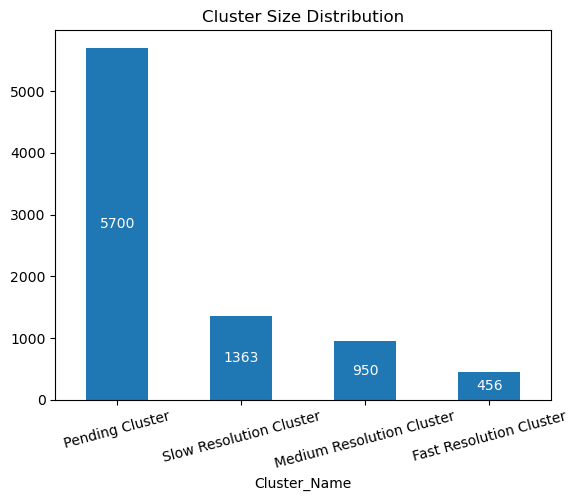

In [8]:
import matplotlib.pyplot as plt

ax = df['Cluster_Name'].value_counts().plot(kind='bar')

plt.title("Cluster Size Distribution")

for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white')

plt.xticks(rotation=15)

plt.show()


In [9]:
df.groupby('Cluster_Name')['Similarity_Score'].mean()

Cluster_Name
Fast Resolution Cluster      1.531792
Medium Resolution Cluster    0.134991
Pending Cluster              0.000000
Slow Resolution Cluster      0.057714
Name: Similarity_Score, dtype: float64

In [10]:
df.groupby('Cluster_Name')['Resolution_Time_Hours'].mean()

Cluster_Name
Fast Resolution Cluster       2.015560
Medium Resolution Cluster     8.093674
Pending Cluster                    NaN
Slow Resolution Cluster      17.994087
Name: Resolution_Time_Hours, dtype: float64

In [ ]:
%pip install seaborn
import seaborn as sns # type: ignore

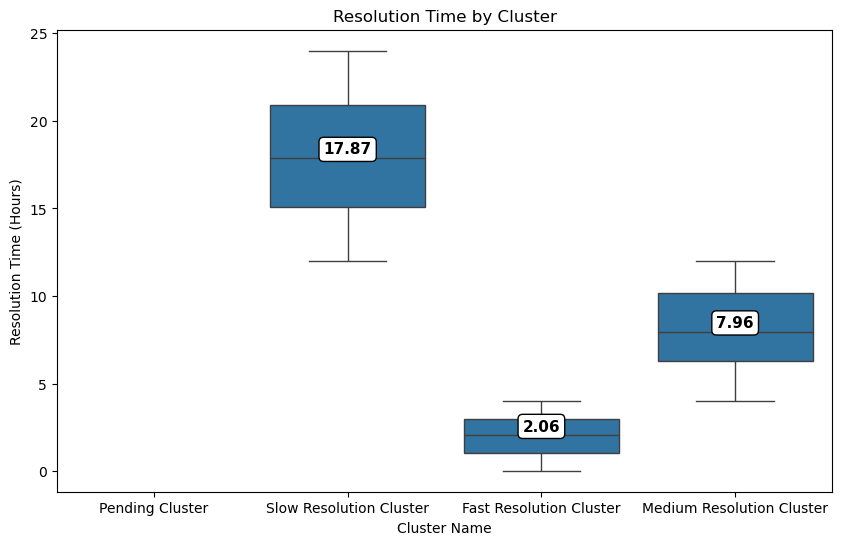

In [12]:
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ax = sns.boxplot(x='Cluster_Name', y='Resolution_Time_Hours', data=df)

medians = df.groupby('Cluster_Name')['Resolution_Time_Hours'].median()

for i, cluster in enumerate(df['Cluster_Name'].unique()):
    median_value = medians.get(cluster)
    
    if pd.notna(median_value):  
        ax.text(
            i, median_value + 0.5,
            f'{median_value:.2f}',
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

plt.title("Resolution Time by Cluster")
plt.xlabel("Cluster Name")
plt.ylabel("Resolution Time (Hours)")

plt.show()


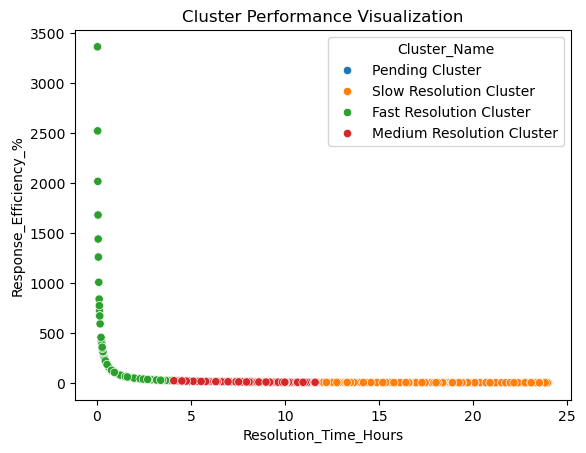

In [13]:
sns.scatterplot(
    x='Resolution_Time_Hours',
    y='Response_Efficiency_%',
    hue='Cluster_Name',
    data=df
)

plt.title("Cluster Performance Visualization")
plt.show()


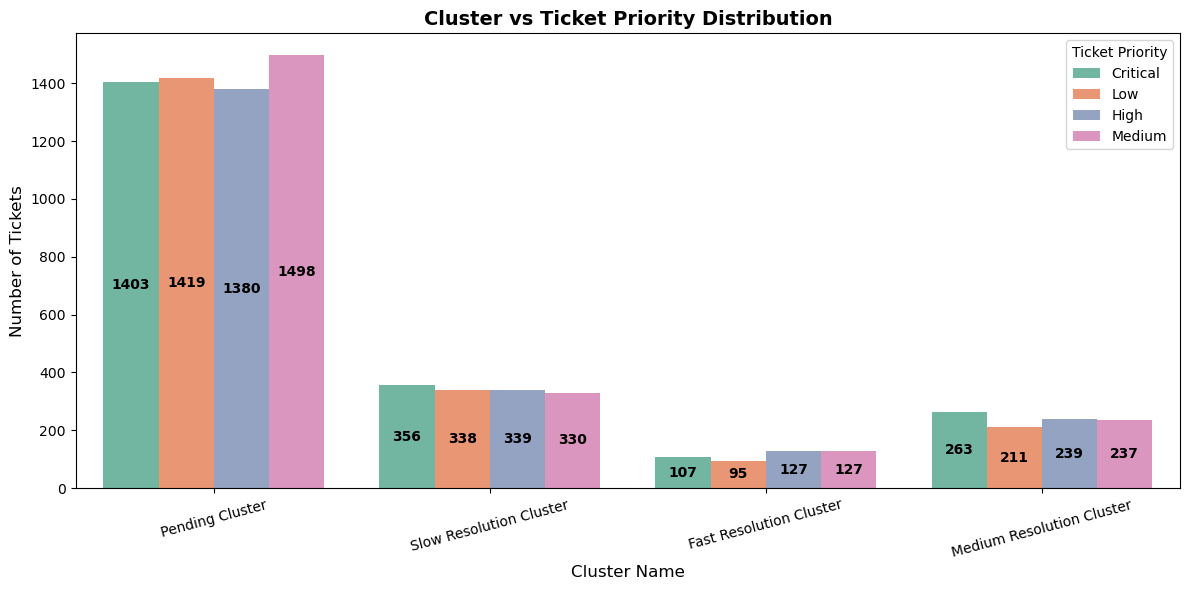

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns # type: ignore

plt.figure(figsize=(12,6))

ax = sns.countplot(
    x='Cluster_Name',
    hue='Ticket Priority',
    data=df,
    palette='Set2'
)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        color='black',
        fontweight='bold',
        fontsize=10
    )

plt.title("Cluster vs Ticket Priority Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Cluster Name", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)

plt.xticks(rotation=15)

plt.legend(title="Ticket Priority")

plt.tight_layout()
plt.show()


In [15]:
import numpy as np

df.loc[df['Resolution_Time_Hours'] <= 0, 'Resolution_Time_Hours'] = np.nan

min_time = df['Resolution_Time_Hours'].min()

df['Response_Efficiency_%'] = (
    min_time / df['Resolution_Time_Hours'] * 100
)

df['Response_Efficiency_%'] = df['Response_Efficiency_%'].replace([np.inf, -np.inf], np.nan)


In [16]:
cluster_summary = df.groupby('Cluster_Name').agg(
    Ticket_Count=('Ticket ID', 'count'),
    Avg_Resolution_Time=('Resolution_Time_Hours', 'mean'),
    Median_Resolution_Time=('Resolution_Time_Hours', 'median'),
    Avg_Response_Efficiency=('Response_Efficiency_%', 'mean'),
    Avg_Priority_Score=('Priority_Score', 'mean')
).round(2)

print(cluster_summary)


                           Ticket_Count  Avg_Resolution_Time  \
Cluster_Name                                                   
Fast Resolution Cluster             456                 2.02   
Medium Resolution Cluster           950                 8.09   
Pending Cluster                    5700                  NaN   
Slow Resolution Cluster            1363                17.99   

                           Median_Resolution_Time  Avg_Response_Efficiency  \
Cluster_Name                                                                 
Fast Resolution Cluster                      2.06                     4.61   
Medium Resolution Cluster                    7.96                     0.40   
Pending Cluster                               NaN                      NaN   
Slow Resolution Cluster                     17.87                     0.17   

                           Avg_Priority_Score  
Cluster_Name                                   
Fast Resolution Cluster                  2.54  
Me

In [17]:
cluster_summary.to_excel("cluster_performance_summary.xlsx")

In [18]:
best_cluster = cluster_summary['Avg_Response_Efficiency'].idxmax()
worst_cluster = cluster_summary['Avg_Response_Efficiency'].idxmin()

print("Best Performing Cluster:", best_cluster)
print("Worst Performing Cluster:", worst_cluster)

Best Performing Cluster: Fast Resolution Cluster
Worst Performing Cluster: Slow Resolution Cluster


In [19]:
most_common_cluster = df['Cluster_Name'].value_counts().idxmax()

print("Most Frequent Cluster:", most_common_cluster)

Most Frequent Cluster: Pending Cluster


In [20]:
similarity_summary = df.groupby('Cluster_Name')['Similarity_Score'].mean().round(4)

print(similarity_summary)

Cluster_Name
Fast Resolution Cluster      1.5318
Medium Resolution Cluster    0.1350
Pending Cluster              0.0000
Slow Resolution Cluster      0.0577
Name: Similarity_Score, dtype: float64


In [21]:
similarity_summary.to_excel("similarity_score_summary.xlsx")

In [22]:
performance_gap = (
    cluster_summary['Avg_Resolution_Time'].max() -
    cluster_summary['Avg_Resolution_Time'].min()
)

print("Performance Gap (Hours):", round(performance_gap, 2))

Performance Gap (Hours): 15.97


## Key Insights from Cluster and Similarity Analysis



### Insight 1: Fast Resolution Cluster Performance
The **Fast Resolution Cluster** has the lowest average resolution time and the highest response efficiency. This indicates optimal support performance, where issues are resolved quickly and efficiently. This cluster represents the best-performing support operations.

---

### Insight 2: Slow Resolution Cluster Performance Bottleneck
The **Slow Resolution Cluster** shows significantly higher resolution time compared to other clusters. This indicates performance bottlenecks, possibly due to complex issues, insufficient resources, or delayed response times. This cluster highlights areas needing performance improvement.

---

### Insight 3: Pending Cluster Indicates Support Backlog
The **Pending Cluster** contains tickets with no resolution time, indicating unresolved or open tickets. This suggests a backlog in the support system and highlights the need for faster response and better workload management.

---

### Insight 4: Similarity Score Confirms Efficiency Trends
The **Similarity Score analysis** confirms that clusters with lower resolution time have higher similarity scores and higher efficiency. This demonstrates a strong relationship between faster resolution and better support performance.

---

### Insight 5: Significant Performance Gap Between Clusters
There is a clear performance gap between the Fast Resolution Cluster and Slow Resolution Cluster. The Fast Cluster resolves issues much quicker, while the Slow Cluster takes significantly longer. This gap indicates opportunities for process optimization and performance improvement.

In [23]:
df.to_excel("final_clustered_dataset.xlsx", index=False)